In [1]:
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns

from prophet import Prophet

Importing plotly failed. Interactive plots will not work.


In [2]:
import time
t1 = time.time()
t1

1783345213.0036976

In [3]:
df_rtc = pd.read_excel("C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/Cambridge Spark/RTC_TIME_SERIES/Raw_data/RTC_raw_data.xlsx")
df = df_rtc.copy()
df.columns
df = df.drop(columns = [ 'IsRTC','ResponsiblePartyStationId', 'IncidentCategory', 'LocationDescription','Eastings', 'Northings'])
df

,FRSIncidentIdentifier,TimeOfCall
0,000012-01042020,2020-04-01 02:29:49
1,000014-01042022,2022-04-01 03:43:14
2,000015-01042022,2022-04-01 03:57:49
3,000018-01012016,2016-01-01 02:49:42
4,000025-01042018,2018-04-01 12:18:07
...,...,...
7325,TO027602-30112025,2025-11-30 16:43:31
7326,TO029187-16122025,2025-12-16 21:54:14
7327,TO029878-16022019,2019-02-16 15:12:32
7328,TO032910-31032019,2019-03-31 07:20:16


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7330 entries, 0 to 7329
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   FRSIncidentIdentifier  7330 non-null   object        
 1   TimeOfCall             7330 non-null   datetime64[us]
dtypes: datetime64[us](1), object(1)
memory usage: 114.7+ KB


In [5]:
df=df[df['TimeOfCall'] > '2011-03-01']

In [6]:
df = df[df['TimeOfCall'] < '2025-12-31']

In [7]:
df['TimeOfCall'] = pd.to_datetime(df['TimeOfCall'])
#counts = pd.Series(index=df.TimeOfCall, data=np.array(df.count)).resample('W').count()
#counts = df.resample('ME', on='TimeOfCall').count()
counts = df.resample('W', on='TimeOfCall').count()
print(counts[10:])


            FRSIncidentIdentifier
TimeOfCall                       
2011-05-15                     12
2011-05-22                      5
2011-05-29                      6
2011-06-05                      5
2011-06-12                     11
...                           ...
2025-12-07                      9
2025-12-14                      8
2025-12-21                      9
2025-12-28                      3
2026-01-04                      2

[765 rows x 1 columns]


In [8]:
counts['FRSIncidentIdentifier']

TimeOfCall
2011-03-06     3
2011-03-13     6
2011-03-20    11
2011-03-27     4
2011-04-03    16
              ..
2025-12-07     9
2025-12-14     8
2025-12-21     9
2025-12-28     3
2026-01-04     2
Freq: W-SUN, Name: FRSIncidentIdentifier, Length: 775, dtype: int64

<Axes: xlabel='TimeOfCall'>

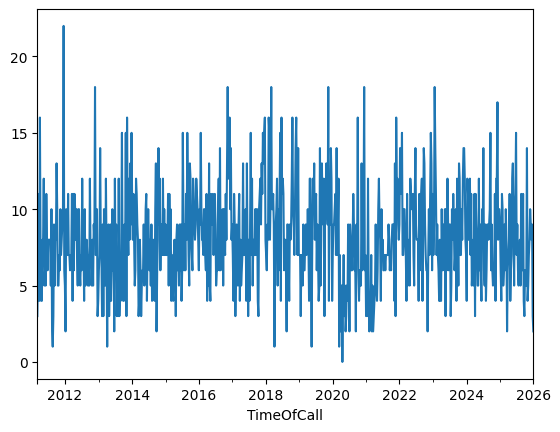

In [9]:
counts['FRSIncidentIdentifier'].plot()

In [10]:
df = pd.DataFrame(counts)
df.reset_index(inplace= True)
df = df.rename(columns = {'TimeOfCall':'ds', 'FRSIncidentIdentifier':'y'})
df.head(2)

,ds,y
0,2011-03-06,3
1,2011-03-13,6


In [11]:
## Extracting weather data from our bikes.csv 

In [12]:
df_bikes = pd.read_csv("C:/Users/pw347789/OneDrive - Oxfordshire County Council/Desktop/Cambridge Spark/RTC_TIME_SERIES/Raw_data/bikes.csv")
df_bikes.date = df_bikes['date'].astype('datetime64[ns]')

df_bikes.info()

<class 'pandas.DataFrame'>
RangeIndex: 729 entries, 0 to 728
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         729 non-null    datetime64[ns]
 1   temperature  729 non-null    float64       
 2   humidity     729 non-null    float64       
 3   windspeed    729 non-null    float64       
dtypes: datetime64[ns](1), float64(3)
memory usage: 22.9 KB


In [13]:
df = df.merge(df_bikes, left_on = 'ds', right_on = 'date', how = 'left')
df = df.drop(columns = ['date'])
df

,ds,y,temperature,humidity,windspeed
0,2011-03-06,3,23.758479,41.075083,21.758202
1,2011-03-13,6,8.972360,51.888144,15.753517
2,2011-03-20,11,16.156669,58.523632,22.928510
3,2011-03-27,4,6.089904,41.760873,19.279918
4,2011-04-03,16,5.959733,55.382923,18.207691
...,...,...,...,...,...
770,2025-12-07,9,NaN,NaN,NaN
771,2025-12-14,8,NaN,NaN,NaN
772,2025-12-21,9,NaN,NaN,NaN
773,2025-12-28,3,NaN,NaN,NaN


In [26]:
df['y'].value_counts()
df

,ds,y,temperature,humidity,windspeed
0,2011-03-06,3,23.758479,41.075083,21.758202
1,2011-03-13,6,8.972360,51.888144,15.753517
2,2011-03-20,11,16.156669,58.523632,22.928510
3,2011-03-27,4,6.089904,41.760873,19.279918
4,2011-04-03,16,5.959733,55.382923,18.207691
...,...,...,...,...,...
770,2025-12-07,9,NaN,NaN,NaN
771,2025-12-14,8,NaN,NaN,NaN
772,2025-12-21,9,NaN,NaN,NaN
773,2025-12-28,3,NaN,NaN,NaN


In [15]:
df = df.sort_values(by = 'ds')
split_index = int(len(df) * 0.8)
train_df = df.iloc[:split_index]
test_df  = df.iloc[split_index:]

print(f"Training on {len(train_df)} rows, testing on {len(test_df)}")

Training on 620 rows, testing on 155


In [16]:
#forecast_model = Prophet(yearly_seasonality=3,
#                         weekly_seasonality=3,
#                         daily_seasonality=True)

forecast_model = Prophet(yearly_seasonality=1,
                         weekly_seasonality=1,
                         daily_seasonality=True)


t1 = time.time()
forecast_model.fit(train_df)
t2 = time.time()
print("model execution time", t2-t1)

14:40:14 - cmdstanpy - INFO - Chain [1] start processing
14:40:14 - cmdstanpy - INFO - Chain [1] done processing


model execution time 0.1440443992614746


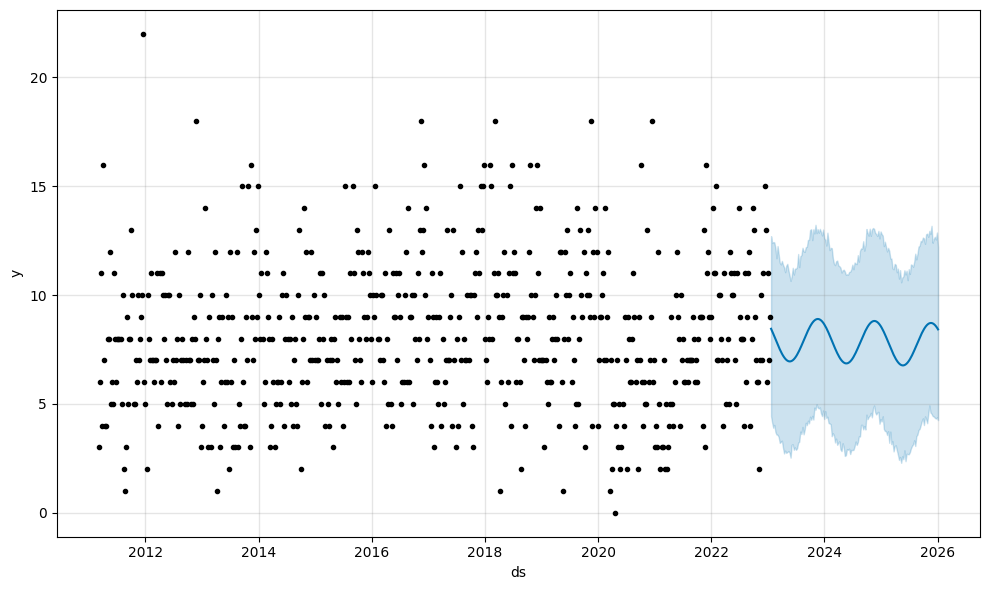

In [17]:
model_predictions = forecast_model.predict(test_df)
model_predictions.head(2)
plot_predictions= forecast_model.plot(model_predictions)

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
test_df = test_df.copy()
test_df['ds'] = pd.to_datetime(test_df['ds'])
results = pd.merge(test_df[['ds','y']], model_predictions[['ds', 'yhat']],on = 'ds' )
actuals = results['y']
predictions = results['yhat']

mae  = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))
mape = np.mean(np.abs((actuals-predictions)/(actuals+1e-10)))*100

print("----Model Evaluation Metrics----")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}")

----Model Evaluation Metrics----
MAE: 2.53
RMSE: 3.10
MAPE: 39.23


In [21]:
# forecast_model with regressors

forecast_model = Prophet(
                        yearly_seasonality=3,
                        weekly_seasonality=3,
                        daily_seasonality=False)

t1 = time.time()
#forecast_model.add_regressor('temperature')
#forecast_model.add_regressor('humidity')
#forecast_model.add_regressor('windspeed')

forecast_model.fit(train_df)
t2 = time.time()

print("model execution time", t2-t1)

14:40:49 - cmdstanpy - INFO - Chain [1] start processing
14:40:49 - cmdstanpy - INFO - Chain [1] done processing


model execution time 0.11785101890563965


In [22]:
model_predictions = forecast_model.predict(test_df)

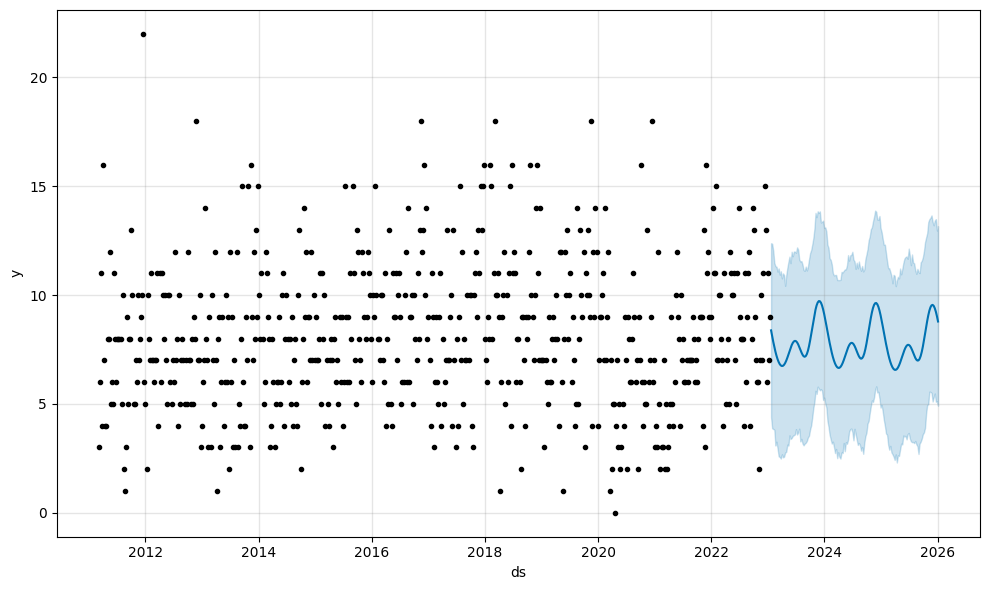

In [23]:
plot_predictions= forecast_model.plot(model_predictions)

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
test_df = test_df.copy()
test_df['ds'] = pd.to_datetime(test_df['ds'])

results = pd.merge(test_df[['ds','y']], model_predictions[['ds', 'yhat']],on = 'ds' )
actuals = results['y']
predictions = results['yhat']

mae  = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))
mape = np.mean(np.abs((actuals-predictions)/(actuals+1e-10)))*100

print("----Model Evaluation Metrics----")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}")

----Model Evaluation Metrics----
MAE: 2.52
RMSE: 3.06
MAPE: 38.93


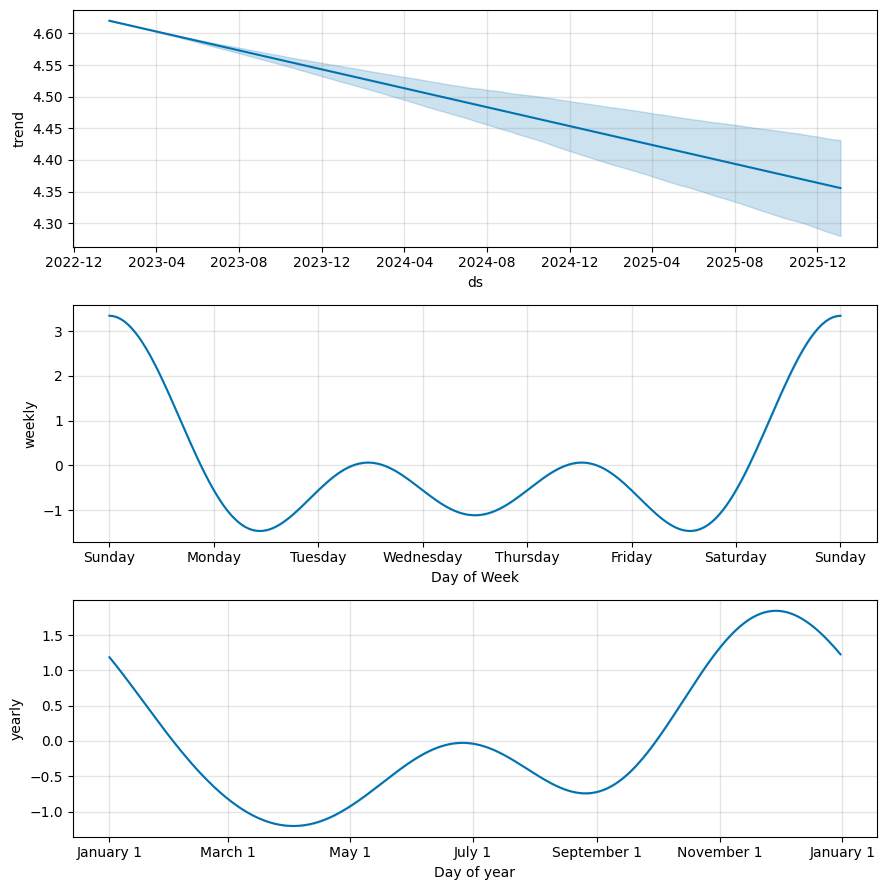

In [25]:
plot_components = forecast_model.plot_components(model_predictions);